# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09
W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


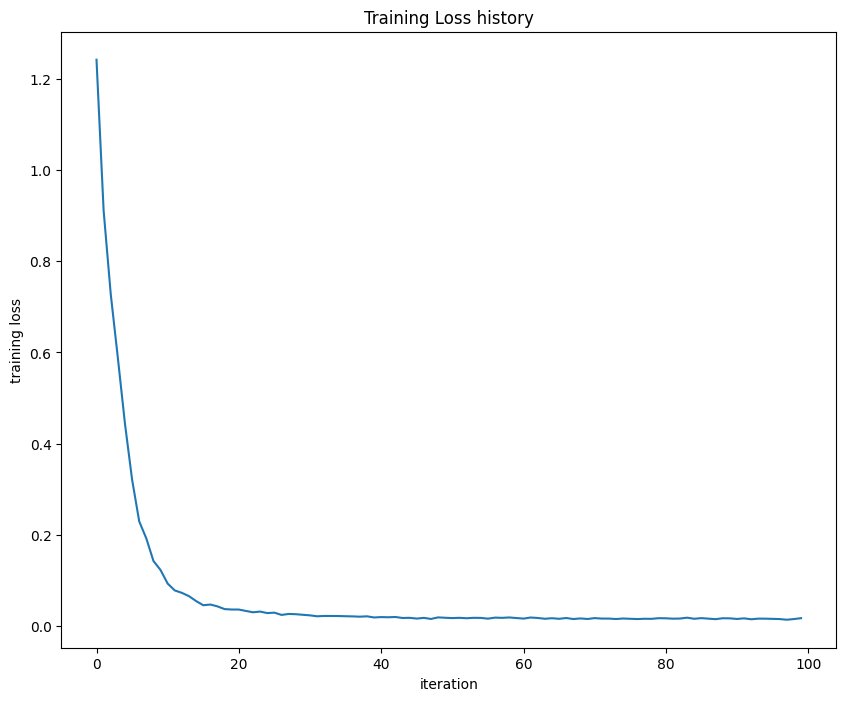

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])

plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

In [7]:
from sklearn.datasets import load_digits
digits = load_digits()

Разделите данные на обучающую, тестовую и валидационную выборки.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (1257, 64)
Training labels shape:  (1257,)
Validation data shape:  (270, 64)
Validation labels shape:  (270,)
Test data shape:  (270, 64)
Test labels shape:  (270,)


Выполните предобработку данных, как в ЛР 1.

(вычитание среднего изображения, рассчитанного по обучающей выборке)

[0.00000000e+00 3.21400159e-01 5.21161496e+00 1.17979316e+01
 1.18607796e+01 5.74065235e+00 1.35481305e+00 1.41607001e-01
 5.56881464e-03 2.02943516e+00]


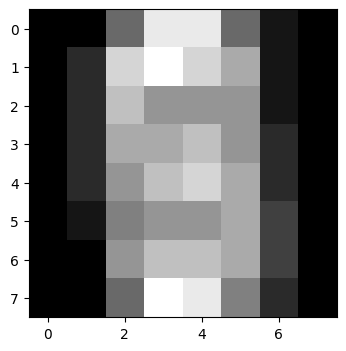

In [9]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape(8,8).astype('uint8')) 
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

Обучите нейронную сеть на ваших данных. 

In [10]:
input_size = 64
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302595
iteration 100 / 1000: loss 2.302591
iteration 200 / 1000: loss 2.302592
iteration 300 / 1000: loss 2.302593
iteration 400 / 1000: loss 2.302586
iteration 500 / 1000: loss 2.302590
iteration 600 / 1000: loss 2.302593
iteration 700 / 1000: loss 2.302594
iteration 800 / 1000: loss 2.302589
iteration 900 / 1000: loss 2.302591
Validation accuracy:  0.0962962962962963


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. (Получилось ещё меньше - 0.096)

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Ранее была реализована нейронная сеть, состоящая только из двух полносвязных слоев. Снаяала просто подберу гиперпараметры для этой нейронной сети

In [11]:
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3]
hidden_sizes = [32, 64, 128, 256]
regs = [1e-4, 5e-4, 1e-3, 5e-3]
num_epochs_list = [20, 50, 100]
batch_size = 64

best_val_acc = 0
best_params = None
best_net = None
best_stats = None

# Вычисляем итераций на эпоху
iters_per_epoch = int(X_train.shape[0] / batch_size)

for lr in learning_rates:
    for hidden_size in hidden_sizes:
        for reg in regs:
            for num_epochs in num_epochs_list:
                
                num_iters = num_epochs * iters_per_epoch
                
                net = TwoLayerNet(input_size, hidden_size, num_classes, std=1e-2)
                
                stats = net.train(
                    X_train, y_train, X_val, y_val,
                    num_iters=num_iters,
                    batch_size=batch_size,
                    learning_rate=lr,
                    learning_rate_decay=0.95,
                    reg=reg,
                    verbose=False
                )
                
                val_acc = (net.predict(X_val) == y_val).mean()
                
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_params = {'lr': lr, 'hidden_size': hidden_size, 'reg': reg, 'epochs': num_epochs}
                    best_net = net
                    best_stats = stats
                    print(f'New best! lr={lr}, hidden={hidden_size}, reg={reg}, epochs={num_epochs}, val_acc={val_acc:.4f}')

print(f'\nЛучшие параметры: {best_params}')
print(f'Лучшая валидационная accuracy: {best_val_acc:.4f}')

New best! lr=0.0001, hidden=32, reg=0.0001, epochs=20, val_acc=0.0926
New best! lr=0.0001, hidden=32, reg=0.0001, epochs=50, val_acc=0.1222
New best! lr=0.0001, hidden=32, reg=0.0005, epochs=20, val_acc=0.1296
New best! lr=0.0001, hidden=32, reg=0.0005, epochs=50, val_acc=0.2407
New best! lr=0.0001, hidden=64, reg=0.0001, epochs=100, val_acc=0.3296
New best! lr=0.0001, hidden=256, reg=0.0005, epochs=50, val_acc=0.3407
New best! lr=0.0005, hidden=32, reg=0.0001, epochs=20, val_acc=0.3593
New best! lr=0.0005, hidden=32, reg=0.0001, epochs=50, val_acc=0.3852
New best! lr=0.0005, hidden=32, reg=0.0001, epochs=100, val_acc=0.3889
New best! lr=0.0005, hidden=32, reg=0.0005, epochs=100, val_acc=0.4593
New best! lr=0.0005, hidden=64, reg=0.0001, epochs=50, val_acc=0.5000
New best! lr=0.0005, hidden=64, reg=0.0001, epochs=100, val_acc=0.6259
New best! lr=0.0005, hidden=128, reg=0.0001, epochs=100, val_acc=0.6444
New best! lr=0.0005, hidden=128, reg=0.0005, epochs=50, val_acc=0.6630
New best! lr

При сдаче лабораторной работы объясните значения всех параметров метода train.

- `X`, `y`, `X_val`, `y_val` - обучающаяя и валидационная выборки.
- `learning_rate` - размер шага градиентного спуска. Определяет, насколько сильно обновлять веса на каждом шаге. Слишком большой - модель расходится, слишком маленький - застревает.
- `learning_rate_decay` - коэффициент уменьшения скорости обучения. После каждой эпохи learning_rate умножается на это число. Помогает модели «успокоиться» и точнее найти минимум в конце обучения.
- `reg` - сила L2-регуляризации. Штрафует модель за большие значения весов, предотвращая переобучение.
- `num_iters` - общее количество шагов градиентного спуска (сколько мини-батчей обработать за всё обучение).
- `batch_size` - размер мини-батча. Сколько примеров брать для одного шага SGD. Влияет на шум градиента и скорость одного шага.

Для лучшей модели вычислите acсuracy на тестовом наборе. 

In [12]:
y_test_pred = best_net.predict(X_test)
test_acc = np.mean(y_test_pred == y_test)
print(f'Best Validation Accuracy: {best_val_acc:.4f}')
print(f'Test Accuracy:            {test_acc:.4f}')

Best Validation Accuracy: 0.9593
Test Accuracy:            0.9074


Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

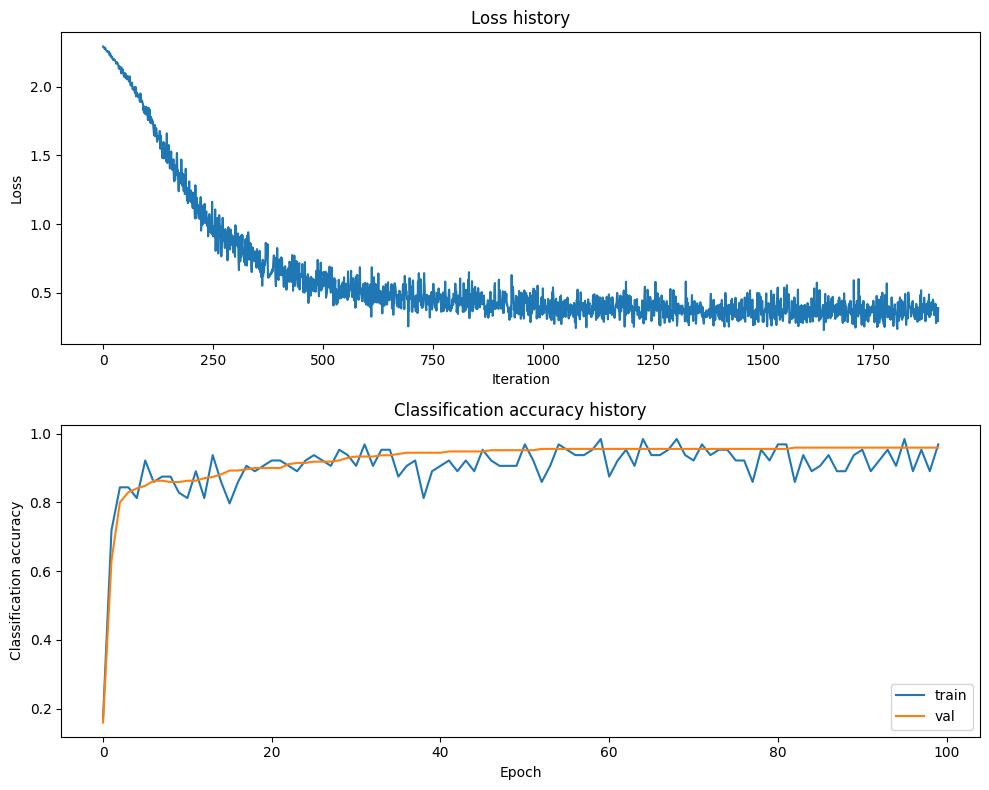

In [13]:
plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc_history'], label='train')
plt.plot(best_stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.tight_layout()
plt.show()

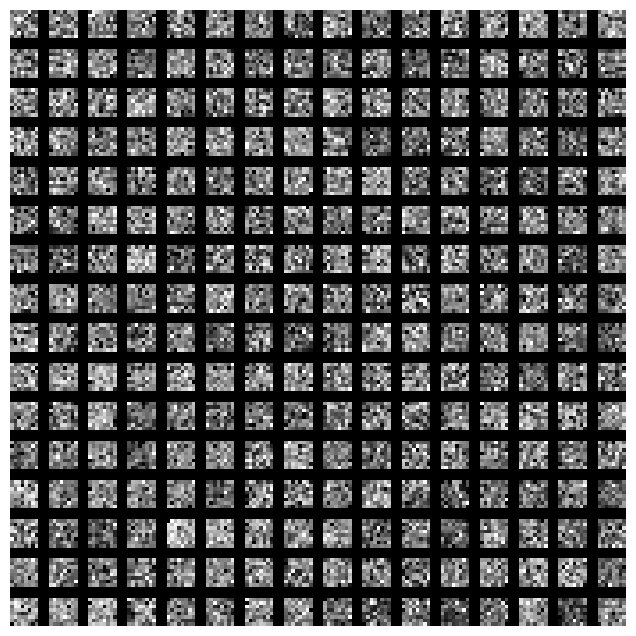

In [14]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(-1, 8, 8, 1) 
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(best_net)

Так как различные эксперементы приветствуются, я возьму уже реализованный MyMLP в рамках курса по машинному обучению. 

Подробнее можно посмотреть: [Реализация многослойного перцептрона с обратным распространением ошибки](../../ml/lab_4.ipynb).

Преимуществам реализованного MyMLP:
1. Гибкая архитектура (не ограничен двумя слоями)
2. Продвинутые оптимизаторы (Adam, RMSprop, SGD с Momentum)
3. Мощная защита от переобучения (Регуляризация)
    - Dropout
    - L2-регуляризация
    - Batch Normalization
    - Early Stopping
4. Инициализация весов (поддержка Xavier и He инициализации)
5. Различные функции активации
6. Векторизованные вычисления

Обучим уже 3-слойную нейронную сеть с подбором гимперпараметров

In [15]:
from scripts.classifiers.my_mlp import MyMLP

SEED = 42
np.random.seed(SEED)
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3]
hidden_sizes_1 = [64, 128, 256]
hidden_sizes_2 = [32, 64]
l2_lambdas = [0.0, 1e-4, 1e-3]
dropout_rates = [0.0, 0.2]

epochs = 30
batch_size = 64

best_val_acc = 0
best_params = None
best_mlp = None

# Перебор
for lr in learning_rates:
    for h1 in hidden_sizes_1:
        for h2 in hidden_sizes_2:
            for l2 in l2_lambdas:
                for dr in dropout_rates:
                    np.random.seed(SEED)
                    
                    mlp = MyMLP(
                        layer_sizes=[input_size, h1, h2, 10],
                        activations=['relu', 'relu', 'softmax'],
                        weight_init='he',
                        optimizer='adam',
                        lr=lr,
                        l2_lambda=l2,
                        dropout_rate=dr
                    )
                    
                    stats = mlp.fit(
                        X_train, y_train, 
                        X_val, y_val, 
                        epochs=epochs, 
                        batch_size=batch_size,
                        output=False
                    )
                    
                    val_acc = np.mean(mlp.predict(X_val) == y_val)
                    
                    if val_acc > best_val_acc:
                        best_val_acc = val_acc
                        best_params = {
                            'lr': lr,
                            'hidden_1': h1,
                            'hidden_2': h2,
                            'l2_lambda': l2,
                            'dropout_rate': dr
                        }
                        best_mlp = mlp
                        best_stats = stats
                        print(f'New best! lr={lr}, h1={h1}, h2={h2}, l2={l2}, dr={dr} - val_acc={val_acc:.4f}')

print(f'\nЛучшие параметры: {best_params}')
print(f'Лучшая валидационная accuracy: {best_val_acc:.4f}')

New best! lr=0.0001, h1=64, h2=32, l2=0.0, dr=0.0 - val_acc=0.7074
New best! lr=0.0001, h1=64, h2=64, l2=0.0, dr=0.0 - val_acc=0.8000
New best! lr=0.0001, h1=64, h2=64, l2=0.0, dr=0.2 - val_acc=0.8148
New best! lr=0.0001, h1=128, h2=32, l2=0.0, dr=0.0 - val_acc=0.8519
New best! lr=0.0001, h1=128, h2=32, l2=0.0, dr=0.2 - val_acc=0.8593
New best! lr=0.0001, h1=128, h2=64, l2=0.0, dr=0.0 - val_acc=0.8630
New best! lr=0.0001, h1=128, h2=64, l2=0.0, dr=0.2 - val_acc=0.8926
New best! lr=0.0001, h1=256, h2=32, l2=0.0, dr=0.0 - val_acc=0.9000
New best! lr=0.0001, h1=256, h2=32, l2=0.0, dr=0.2 - val_acc=0.9222
New best! lr=0.0001, h1=256, h2=64, l2=0.0, dr=0.0 - val_acc=0.9296
New best! lr=0.0001, h1=256, h2=64, l2=0.0, dr=0.2 - val_acc=0.9519
New best! lr=0.0005, h1=64, h2=64, l2=0.0, dr=0.2 - val_acc=0.9593
New best! lr=0.0005, h1=128, h2=64, l2=0.0, dr=0.2 - val_acc=0.9778
New best! lr=0.0005, h1=256, h2=64, l2=0.0, dr=0.2 - val_acc=0.9889
New best! lr=0.005, h1=256, h2=32, l2=0.0001, dr=0.0

Графики изменения loss и accuracy в процессе обучения:

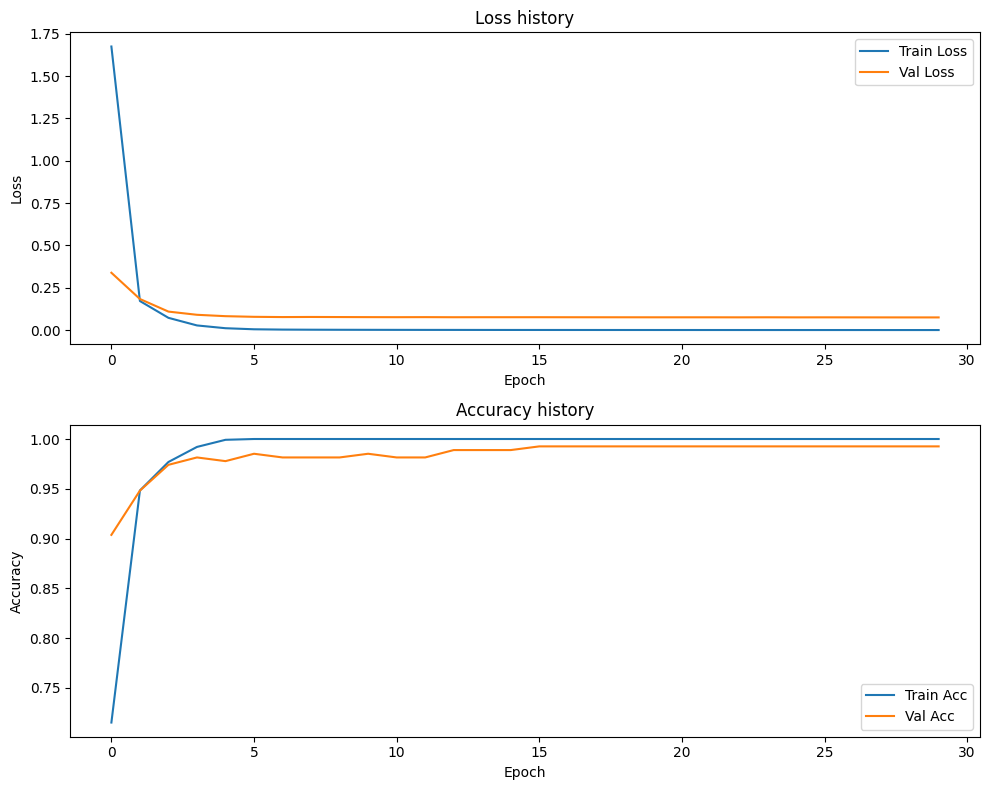

In [16]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(best_stats['train_loss'], label='Train Loss')
plt.plot(best_stats['val_loss'], label='Val Loss')
plt.title('Loss history')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc'], label='Train Acc')
plt.plot(best_stats['val_acc'], label='Val Acc')
plt.title('Accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Точность на тесте:

In [17]:
y_test_pred = best_mlp.predict(X_test)
test_acc = np.mean(y_test_pred == y_test)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.9852


Сделайте выводы по результатам работы. 

В рамках данной лабораторной работы была реализована и исследована двухслойная полносвязная нейронная сеть, решающая задачу многоклассовой классификации.

Выводы:

1. Корректность вычисления градиентов подтверждена методом численной проверки: максимальная относительная ошибка для всех обучаемых параметров не превысила порядка 1e-8, что свидетельствует о верности аналитических выкладок и их программной реализации.

2. Обучение сети на модельной выборке продемонстрировало устойчивую сходимость: значение функции потерь достигло уровня 0.017, что подтверждает работоспособность реализованных методов прямого и обратного проходов.

3. Проведён поиск по сетке гиперпараметров, включающий скорость обучения (learning rate), размеры скрытого слоя, коэффициент L2-регуляризации, количество эпох. Лучшая 2-слойная нейронная сеть продемонстрировала точность на валидационной выборке, равную 0.9593, а на тестовой - 0.9074.

4. Также дополнительно была обучена 3-слойная нейронная сеть с He инициализацией весов и Adam оптимизатором. Здесь тоже был проведён поиск по сетке гиперпараметров. Лучшая модель продемонстрировала точность на валидационной выборке, равную 0.9926, а на тестовой - 0.9852.

    Итоговая архитектура:
    - Входной слой (Input): 64 нейрона.
    - Скрытый слой 1: 256 нейронов, функция активации ReLU.
    - Скрытый слой 2: 32 нейрона, функция активации ReLU.
    - Выходной слой (Output): 10 нейронов (по числу классов цифр), функция активации Softmax.

Таким образом, углубление архитектуры, He-инициализация и оптимизатор Adam позволили поднять точность до 98,52% и обеспечить стабильную сходимость. Минимальный разрыв между валидацией и тестом подтверждает отсутствие переобучения.